In [66]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

from skimage import io, color, filters, transform, util

from scipy.fftpack import dct, idct

In [67]:
img_bgr = cv2.imread('./image.png')

In [68]:
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

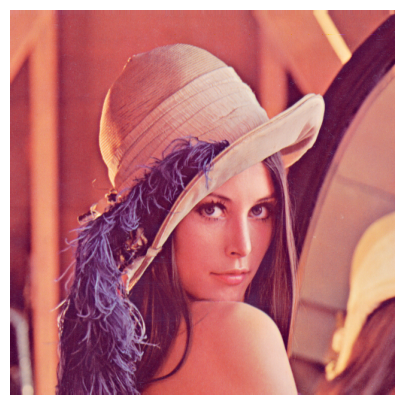

In [69]:
plt.figure(figsize=(5,5))
plt.imshow(img_rgb)
plt.axis('off')
plt.show()

In [70]:
img_ycrcb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2YCrCb)

In [71]:
Y, Cr, Cb = cv2.split(img_ycrcb)

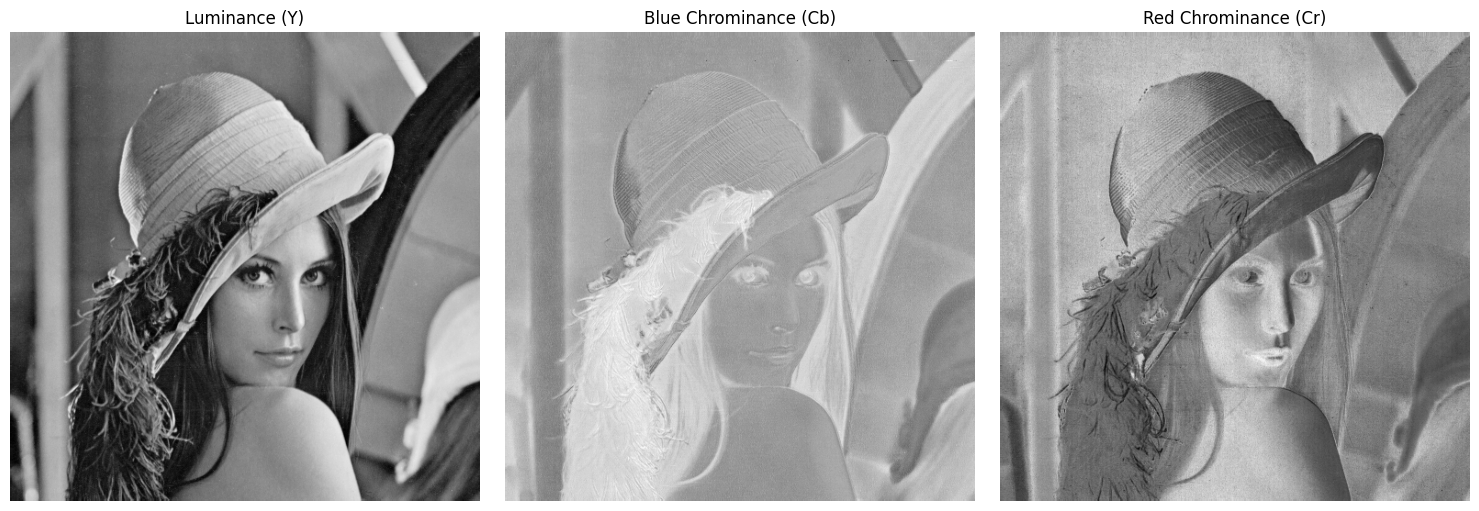

In [72]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(Y, cmap='gray')
axes[0].set_title('Luminance (Y)')
axes[0].axis('off')

axes[1].imshow(Cb, cmap='gray')
axes[1].set_title('Blue Chrominance (Cb)')
axes[1].axis('off')

axes[2].imshow(Cr, cmap='gray')
axes[2].set_title('Red Chrominance (Cr)')
axes[2].axis('off')

plt.tight_layout()
plt.show()


In [73]:
def chroma_subsample(channel):
    h, w = channel.shape
    h, w = h - h % 2, w - w % 2

    channel = channel[:h, :w]

    subsampled = np.zeros((h // 2, w // 2), dtype=np.float32)

    for i in range(0, h, 2):
        for j in range(0, w, 2):
            top_left     = channel[i, j]
            top_right    = channel[i, j+1]
            bottom_left  = channel[i+1, j]
            bottom_right = channel[i+1, j+1]

            average = (top_left + top_right + bottom_left + bottom_right) / 4

            subsampled[i//2, j//2] = average

    return subsampled.astype(np.uint8)

In [74]:
Cb_sub = chroma_subsample(Cb)
Cr_sub = chroma_subsample(Cr)

/tmp/ipython-input-73-1065903909.py:16: RuntimeWarning: overflow encountered in scalar add
  average = (top_left + top_right + bottom_left + bottom_right) / 4


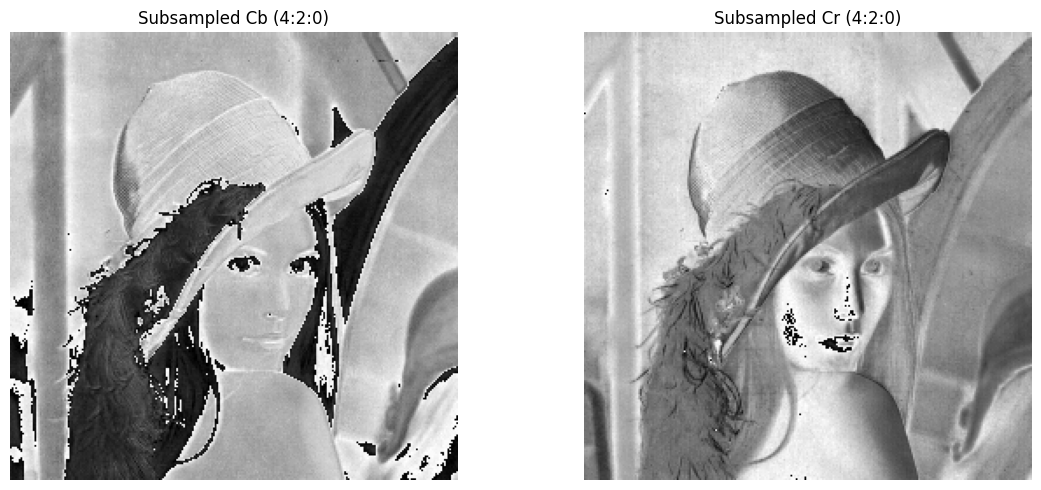

In [75]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].imshow(Cb_sub, cmap='gray')
axes[0].set_title('Subsampled Cb (4:2:0)')
axes[0].axis('off')

axes[1].imshow(Cr_sub, cmap='gray')
axes[1].set_title('Subsampled Cr (4:2:0)')
axes[1].axis('off')

plt.tight_layout()
plt.show()


In [76]:
def split_into_blocks(channel, block_size=8):
    h, w = channel.shape
    h_trim = h - (h % block_size)
    w_trim = w - (w % block_size)
    channel = channel[:h_trim, :w_trim]

    blocks = []
    for i in range(0, h_trim, block_size):
        row_blocks = []
        for j in range(0, w_trim, block_size):
            block = channel[i:i+block_size, j:j+block_size]
            row_blocks.append(block)
        blocks.append(row_blocks)

    return np.array(blocks)

In [77]:
blocks = split_into_blocks(Y, 8)

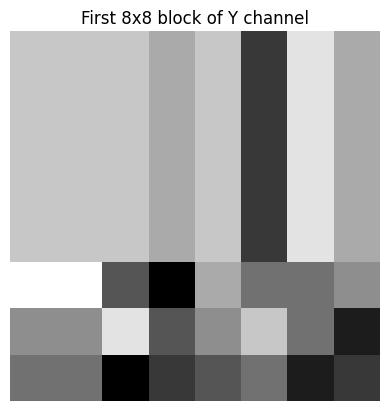

In [78]:
plt.imshow(blocks[0, 0], cmap='gray')
plt.title('First 8x8 block of Y channel')
plt.axis('off')
plt.show()

In [79]:
def dct2D(block):
     return dct(dct(block.T, norm='ortho').T, norm='ortho')

In [80]:
block_8x8 = blocks[0, 0].astype(np.float32)

dct_block = dct2D(block_8x8)

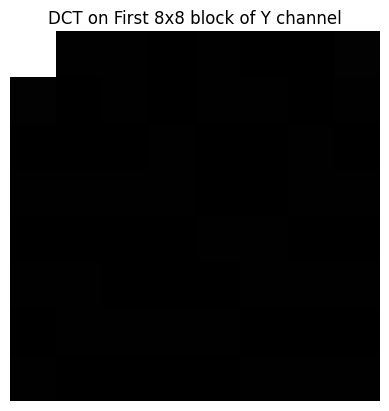

In [81]:
plt.imshow(dct_block, cmap='gray')
plt.title('DCT on First 8x8 block of Y channel')
plt.axis('off')
plt.show()

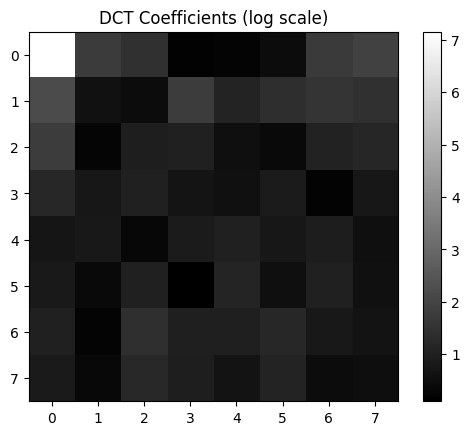

In [82]:
plt.imshow(np.log(np.abs(dct_block) + 1), cmap='gray')
plt.title('DCT Coefficients (log scale)')
plt.colorbar()
plt.show()

In [83]:
Q = np.array([[16, 11, 10, 16, 24, 40, 51, 61],
            [12, 12, 14, 19, 26, 58, 60, 55],
            [14, 13, 16, 24, 40, 57, 69, 56],
            [14, 17, 22, 29, 51, 87, 80, 62],
            [18, 22, 37, 56, 68, 109, 103, 77],
            [24, 35, 55, 64, 81, 104, 113, 92],
            [49, 64, 78, 87, 103, 121, 120, 101],
            [72, 92, 95, 98, 112, 100, 103, 99]])

quantized_block = dct_block/Q

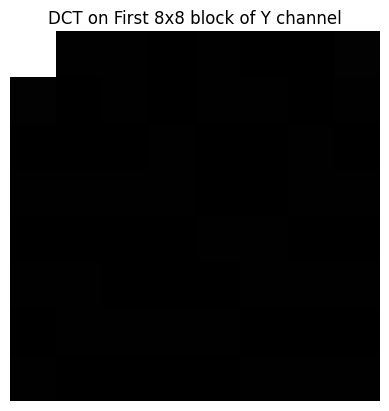

In [84]:
plt.imshow(dct_block, cmap='gray')
plt.title('DCT on First 8x8 block of Y channel')
plt.axis('off')
plt.show()

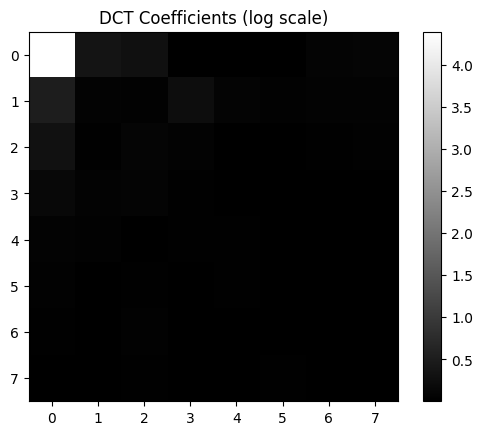

In [85]:
plt.imshow(np.log(np.abs(quantized_block) + 1), cmap='gray')
plt.title('DCT Coefficients (log scale)')
plt.colorbar()
plt.show()

In [86]:
dequantized_block = quantized_block * Q

In [87]:
reconstructed_image = idct(idct(dequantized_block.T, norm ='ortho').T, norm = 'ortho') +128

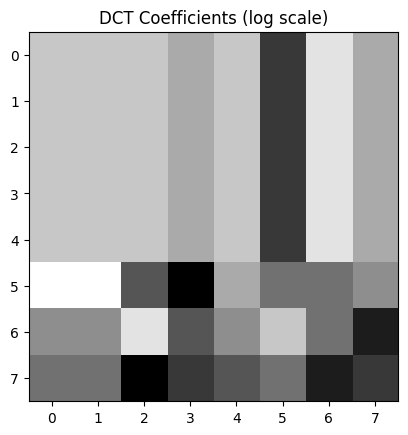

In [88]:
plt.imshow(reconstructed_image, cmap='gray')
plt.title('DCT Coefficients (log scale)')
plt.show()

In [89]:
def calculate_psnr(img1, img2):
    mse = np.mean((img1.astype(np.float32) - img2.astype(np.float32)) ** 2)
    if mse == 0:
        return float('inf')
    max_pixel = 255.0
    psnr = 10 * np.log10((max_pixel ** 2) / mse)
    return psnr

In [99]:
psnr = calculate_psnr(blocks[0,0], reconstructed_image)

In [100]:
print(psnr)

5.9866047
